In [1]:
import sys
sys.path.append("/Users/chris/Documents/higs-vision")

from src.data import load_config, load_processed
from src.models import create_model_from_config
from src.train import train, save_training_run
import matplotlib.pyplot as plt

config = load_config("/Users/chris/Documents/higs-vision/config.yaml")
X_train, y_train, X_val, y_val, X_test, y_test, scaler = load_processed(config)

Loaded processed data from /Users/chris/Documents/higs-vision/data/processed/
  Train: (700000, 28), Val: (150000, 28), Test: (150000, 28)


In [2]:
model = create_model_from_config(config)
model, history = train(model, X_train, y_train, X_val, y_val, config, seed=config["seeds"]["dnn_final"])

Epoch   1 | Train Loss: 0.6110 | Val Loss: 0.5664 | Val AUC: 0.7760 | Time: 19.7s
Epoch   2 | Train Loss: 0.5706 | Val Loss: 0.5423 | Val AUC: 0.7983 | Time: 17.8s
Epoch   3 | Train Loss: 0.5540 | Val Loss: 0.5310 | Val AUC: 0.8081 | Time: 19.7s
Epoch   4 | Train Loss: 0.5439 | Val Loss: 0.5233 | Val AUC: 0.8144 | Time: 16.4s
Epoch   5 | Train Loss: 0.5373 | Val Loss: 0.5185 | Val AUC: 0.8188 | Time: 17.1s
Epoch   6 | Train Loss: 0.5322 | Val Loss: 0.5138 | Val AUC: 0.8225 | Time: 15.2s
Epoch   7 | Train Loss: 0.5280 | Val Loss: 0.5111 | Val AUC: 0.8242 | Time: 15.2s
Epoch   8 | Train Loss: 0.5250 | Val Loss: 0.5093 | Val AUC: 0.8257 | Time: 15.3s
Epoch   9 | Train Loss: 0.5218 | Val Loss: 0.5050 | Val AUC: 0.8292 | Time: 15.5s
Epoch  10 | Train Loss: 0.5197 | Val Loss: 0.5044 | Val AUC: 0.8295 | Time: 15.6s
Epoch  11 | Train Loss: 0.5174 | Val Loss: 0.5026 | Val AUC: 0.8312 | Time: 15.5s
Epoch  12 | Train Loss: 0.5156 | Val Loss: 0.5012 | Val AUC: 0.8320 | Time: 15.3s
Epoch  13 | Trai

In [3]:
save_training_run(model, history, config, "models/dnn/final", seed=config["seeds"]["dnn_final"])

Saved model and run info to models/dnn/final/


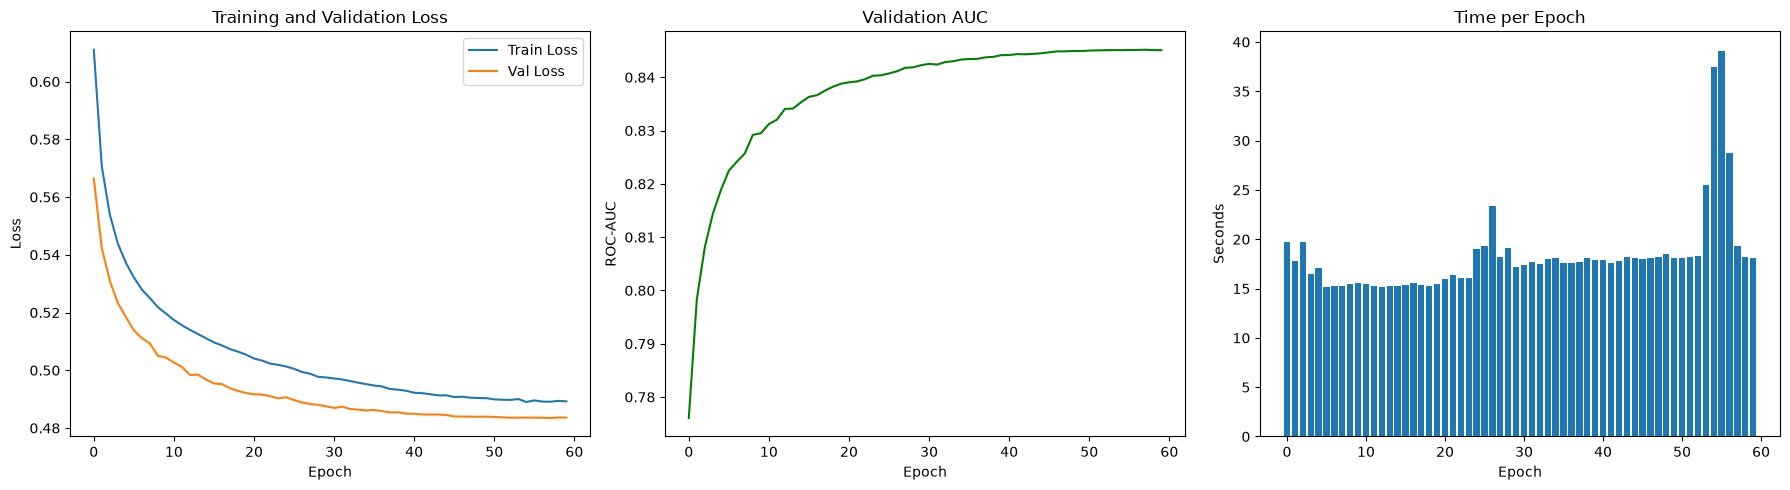

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(history["train_loss"], label="Train Loss")
axes[0].plot(history["val_loss"], label="Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training and Validation Loss")
axes[0].legend()

# AUC
axes[1].plot(history["val_auc"], label="Val AUC", color="green")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("ROC-AUC")
axes[1].set_title("Validation AUC")

# Epoch time
axes[2].bar(range(len(history["epoch_time"])), history["epoch_time"])
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Seconds")
axes[2].set_title("Time per Epoch")

plt.tight_layout()
plt.savefig("/Users/chris/Documents/higs-vision/figures/training_curves.png", dpi=150)
plt.show()

In [5]:
print(f"Training stopped after {len(history['train_loss'])} epochs")
print(f"Best validation AUC: {max(history['val_auc']):.4f}")
print(f"Best validation loss: {min(history['val_loss']):.4f}")
print(f"Total training time: {history['total_time']:.1f}s ({history['total_time']/60:.1f} min)")
print(f"Peak RAM: {history['peak_ram_gb']:.2f} GB")

Training stopped after 60 epochs
Best validation AUC: 0.8452
Best validation loss: 0.4834
Total training time: 1100.4s (18.3 min)
Peak RAM: 0.74 GB


In [6]:
import sys
sys.path.append("/Users/chris/Documents/higs-vision")
import torch
import numpy as np

from src.data import load_config, load_processed
from src.models import create_model_from_config
from src.evaluate import compute_metrics, compute_ece, print_comparison_table

config = load_config("/Users/chris/Documents/higs-vision/config.yaml")
X_train, y_train, X_val, y_val, X_test, y_test, scaler = load_processed(config)

# Load trained DNN
model = create_model_from_config(config)
model.load_state_dict(torch.load("models/dnn/final/model.pt"))
model.eval()

# Predict on test set
with torch.no_grad():
    y_pred_proba = model(torch.FloatTensor(X_test)).squeeze().numpy()

# Compute metrics
dnn_metrics = compute_metrics(y_test, y_pred_proba)
ece, bins = compute_ece(y_test, y_pred_proba)

print_comparison_table({"DNN (default)": dnn_metrics})
print(f"\nECE: {ece}")

Loaded processed data from /Users/chris/Documents/higs-vision/data/processed/
  Train: (700000, 28), Val: (150000, 28), Test: (150000, 28)
Model                Accuracy     Prec   Recall       F1  ROC-AUC   PR-AUC    Brier
------------------------------------------------------------------------------------
DNN (default)          0.7635   0.7674   0.7946   0.7808   0.8471   0.8595   0.1591

ECE: 0.007
